# Reading and importing libraries for data

In [1]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('./Data/train.csv')

In [3]:
df.columns

Index(['CustomerID', 'State', 'Customer Lifetime Value', 'Response',
       'Coverage', 'Coverage Index', 'Education', 'Education Index',
       'Effective To Date', 'Employment Status', 'Employment Status Index',
       'Gender', 'Income', 'Marital Status', 'Marital Status Index',
       'Months Since Last Claim', 'Months Since Policy Inception',
       'Number of Open Complaints', 'Number of Policies', 'Policy Type',
       'Policy Type Index', 'Policy', 'Policy Index', 'Renew Offer Type',
       'Sales Channel', 'Sales Channel Index', 'Vehicle Size',
       'Vehicle Size Index', 'Claim over 1k'],
      dtype='object')

# Data Exploration

In [4]:
columns = df.columns

In [5]:
# Create the DataFrame with Unique_Counts
nunique_df = pd.DataFrame({
    'Column': columns,
    'Unique_Counts': [df[col].nunique() for col in columns],
    'Data_Type': [df[col].dtype for col in columns]  # Adding data types
})

# Add the Description column based on Unique_Counts
nunique_df['Description'] = [
    df[col].unique().tolist() if df[col].nunique() < 10 else None for col in columns
]

In [6]:
nunique_df

,Column,Unique_Counts,Data_Type,Description
0,CustomerID,7290,object,None
1,State,5,object,"[California, Washington, Oregon, Arizona, Nevada]"
2,Customer Lifetime Value,6464,float64,None
3,Response,2,object,"[No, Yes]"
4,Coverage,3,object,"[Basic, Extended, Premium]"
5,Coverage Index,3,int64,"[0, 1, 2]"
6,Education,5,object,"[Bachelor, High School or Below, College, Mast..."
7,Education Index,5,int64,"[2, 0, 1, 3, 4]"
8,Effective To Date,59,object,None
9,Employment Status,5,object,"[Employed, Unemployed, Retired, Medical Leave,..."


# Data Cleaning for Categorical Var

## Creating Mapping Dictionary

In [7]:
# New mapping dict for these categorical variables
mapping_dict = {
    'State': {
        'California': 0,
        'Washington': 1,
        'Oregon': 2,
        'Arizona': 3,
        'Nevada': 4
    },
    'Response': {
        'No': 0,
        'Yes': 1
    },
    'Gender': {
        'F': 0,
        'M': 1
    }
}

# already existing mapping
mapping_dict_existing = {
    
    'Sales Channel': {
        'Web': 0,
        'Branch': 1,
        'Agent': 2,
        'Call Center': 3
    },
    'Coverage': {
        'Basic': 0,
        'Extended': 1,
        'Premium': 2
    },
    'Education': {
        'High School': 0,
        'Bachelor': 1,
        'Master': 2,
        'PhD': 3
    },
    'Employment Status': {
        'Unemployed': 0,
        'Employed': 1,
        'Medical Leave': 2,
        'Retired': 3
    },
    'Marital Status': {
        'Single': 0,
        'Married': 1,
        'Divorced': 2
    },
    'Policy Type': {
        'Personal Auto': 0,
        'Corporate Auto': 1,
        'Special Auto': 2
    },
    'Policy': {
        'Personal L1': 0,
        'Personal L2': 1,
        'Personal L3': 2,
        'Corporate L1': 3,
        'Corporate L2': 4,
        'Corporate L3': 5,
        'Special L1': 6,
        'Special L2': 7,
        'Special L3': 8
    },
    'Vehicle Size': {
        'Small': 0,
        'Medium': 1,
        'Large': 2
    }
}

In [8]:
df_new=df.copy()

In [9]:
for col, mapping in mapping_dict.items():
    if col in df_new.columns:
        # Apply the mapping from the dictionary to the corresponding column in df_new
        df_new[col] = df_new[col].map(mapping)

In [10]:
# drop necessary columns (already has corresponding categorical index)
df_new = df_new.drop(columns=['Coverage', 'Education', 'Employment Status', 'Marital Status', 
                      'Policy Type', 'Policy', 'Vehicle Size','Sales Channel'])

## Data cleaning for Dates

In [11]:
# We will make a nother column called days to calculate the date.
# This 'days' column will contain the number of days since the min date in the data

# Ensure the date column is in datetime format
df_new['Effective To Date'] = pd.to_datetime(df_new['Effective To Date'])

# Find the minimum date
min_date = df_new['Effective To Date'].min()

# Create a new column 'Days' that represents the number of days since the minimum date
df_new['Days'] = (df_new['Effective To Date'] - min_date).dt.days.astype(np.int64)


In [12]:
# we will drop the date for now
df_new.drop(columns=['Effective To Date'], inplace = True)

In [13]:
#df_new['Effective To Date'] = pd.to_datetime(df_new['Effective To Date'])

In [14]:
# Extract useful features from the date column
# Might be better removing the dates because each Year, Month, and Date are being processed as separate categories 
#   This loses the purpose of date.
#df_new['Effective_Year'] = df_new['Effective To Date'].dt.year
#df_new['Effective_Month'] = df_new['Effective To Date'].dt.month
#df_new['Effective_Day'] = df_new['Effective To Date'].dt.day

# Mutual Information Feature Selection

In [15]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7290 entries, 0 to 7289
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7290 non-null   object 
 1   State                          7290 non-null   int64  
 2   Customer Lifetime Value        7290 non-null   float64
 3   Response                       7290 non-null   int64  
 4   Coverage Index                 7290 non-null   int64  
 5   Education Index                7290 non-null   int64  
 6   Employment Status Index        7290 non-null   int64  
 7   Gender                         7290 non-null   int64  
 8   Income                         7290 non-null   int64  
 9   Marital Status Index           7290 non-null   int64  
 10  Months Since Last Claim        7290 non-null   int64  
 11  Months Since Policy Inception  7290 non-null   int64  
 12  Number of Open Complaints      7290 non-null   i

In [16]:
# Define the features (X) and the target variable (y)
X = df_new.drop(columns=['Claim over 1k', 'CustomerID'])  # Exclude target and ID
y = df_new['Claim over 1k']  # Target variable

# Step 3: Calculate Mutual Information for Classification
mi_scores = mutual_info_classif(X, y)

# Create a DataFrame to show MI scores for each feature
mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi_scores})

# Sort the features by MI score in descending order
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

In [28]:
mi_df

,Feature,Mutual Information
1,Customer Lifetime Value,0.064430
7,Income,0.052174
5,Employment Status Index,0.029066
8,Marital Status Index,0.021525
3,Coverage Index,0.021398
15,Renew Offer Type,0.005092
16,Sales Channel Index,0.004356
0,State,0.003927
10,Months Since Policy Inception,0.003062
4,Education Index,0.001053


In [17]:
# Get the list of features with MI score greater than 0
selected_features = mi_df[mi_df['Mutual Information'] > 0]['Feature'].to_list()

# Append the 'Claim over 1k' and 'CustomerID' to the selected features
final_features = selected_features + ['Claim over 1k', 'CustomerID']

In [18]:
final_df = df_new[final_features]

## Logistic Regression

### Assumptions for Logistic Regression

- Binary Outcome

- Linearity of Logit: The assumption is that $\quad logit(\frac{p}{1-p}) = \beta_0 + \beta_1 X_1 + ... + \beta_nX_n$

- No Multicollinearity: $X_i$ s are all independent with each other. This means our features should be independent with each other (Was tested using VIF, not detected).

- Independence of Observations: We should assume each customers are independent from each other, thus assuming no claims are caused by each other.

Looks like some features do not meet the assumption for linearity. Logistic Regression Might not be good choice

In [19]:
# import matplotlib.pyplot as plt  # Importing matplotlib for plotting
# tmp = final_df  # Create a copy of the 'final_df' DataFrame to work on, to avoid modifying the original data

# # Bin the continuous variable (e.g., Income) into equal-sized bins
# # The pd.cut() function divides the 'Income' variable into 10 bins, creating intervals (e.g., (1000, 2000])
# tmp['income_bins'] = pd.cut(tmp['Income'], bins=10)

# # Calculate the mean value of the binary outcome (Claim over 1k) for each bin.
# # This step groups the data by the income bins and computes the average probability of Claim over 1k for each bin.
# bin_means = tmp.groupby('income_bins')['Claim over 1k'].mean()

# # Remove bins where the mean probability is exactly 0 or 1 to avoid log(0) issues when calculating log-odds.
# valid_bins = (bin_means > 0) & (bin_means < 1)  # Only keep bins with probabilities between 0 and 1.
# bin_means = bin_means[valid_bins]  # Filter out invalid bins from 'bin_means'.

# # Calculate the log-odds for the remaining bins.
# # The log-odds are calculated as log(p / (1 - p)), where p is the probability of Claim over 1k for each bin.
# log_odds = np.log(bin_means / (1 - bin_means))

# # Calculate the midpoints of the income bins to use as the x-axis values for plotting.
# # This lambda function extracts the midpoint of each bin (e.g., midpoint of (1000, 2000] is 1500).
# bin_midpoints = tmp['income_bins'].apply(lambda x: x.mid)

# # Filter out midpoints that correspond to invalid bins (those we filtered out in 'bin_means').
# bin_midpoints = bin_midpoints[valid_bins]

# # Drop duplicates (since midpoints can repeat within bins) to ensure unique midpoints.
# bin_midpoints = bin_midpoints.drop_duplicates()

# # Plot the log-odds vs. the midpoints of the income bins using a scatter plot.
# # The midpoints are plotted on the x-axis, and the log-odds are plotted on the y-axis.
# plt.scatter(bin_midpoints, log_odds)
# plt.xlabel('Income (Bin Midpoints)')  # Label for the x-axis
# plt.ylabel('Log-Odds of Claim over 1k')  # Label for the y-axis
# plt.title('Log-Odds vs Income')  # Title of the plot
# plt.show()  # Display the plot


In [20]:
#from statsmodels.stats.outliers_influence import variance_inflation_factor
# Ensure 'CustomerID' and 'Claim over 1k' are excluded
#X = final_df.drop(columns=['CustomerID', 'Claim over 1k'])

# Calculate VIF
#vif_data = pd.DataFrame()
#vif_data['Feature'] = X.columns
#vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
#print(vif_data)
## Multi colinearity was not detected



## Random Forest

### Assumptions

- Independence of observations

In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

## Prepare Data
# Separate features and target variable
X = final_df.drop(columns=['Claim over 1k', 'CustomerID'])  # Features
y = final_df['Claim over 1k']  # Target variable


## Train test split
# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## initialize and train the random forest model
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 trees in the forest

# Train the model on the training data
rf_model.fit(X_train, y_train)


## Make Predictions
# Make predictions on the test set
y_pred = rf_model.predict(X_test)


## Evaluate the model
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate a detailed classification report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])  # For binary classification
print(f"ROC-AUC Score: {roc_auc:.4f}")


Accuracy: 0.9060
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1300
           1       0.67      0.26      0.37       158

    accuracy                           0.91      1458
   macro avg       0.79      0.62      0.66      1458
weighted avg       0.89      0.91      0.89      1458

ROC-AUC Score: 0.8498


In [38]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees
    'max_depth': [10, 20, 30],              # Maximum depth of trees
    'min_samples_split': [2, 5, 10],        # Minimum number of samples to split
    'min_samples_leaf': [1, 2, 5],          # Minimum number of samples in a leaf
    'max_features': ['sqrt', 'log2'],       # Maximum features for each split
    'class_weight': ['balanced']            # Use class weights if imbalanced
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best hyperparameters
best_params = grid_search.best_params_

# Use the best estimator from GridSearchCV to make predictions
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best = best_rf_model.predict(X_test)

# Evaluate the best model

# Calculate accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy of Best Model: {accuracy_best:.4f}")

# Generate a detailed classification report (Precision, Recall, F1-Score)
print("Classification Report of Best Model:")
print(classification_report(y_test, y_pred_best))

# Calculate the ROC-AUC score for the best model
roc_auc_best = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])  # For binary classification
print(f"ROC-AUC Score of Best Model: {roc_auc_best:.4f}")

# Display the best hyperparameters found by GridSearchCV
print("\nBest Hyperparameters found by Grid Search:")
for param_name in best_params:
    print(f"{param_name}: {best_params[param_name]}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits


c:\Users\06pau\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Accuracy of Best Model: 0.9088
Classification Report of Best Model:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1300
           1       0.73      0.25      0.38       158

    accuracy                           0.91      1458
   macro avg       0.82      0.62      0.66      1458
weighted avg       0.90      0.91      0.89      1458

ROC-AUC Score of Best Model: 0.8589

Best Hyperparameters found by Grid Search:
class_weight: balanced
max_depth: 30
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 200


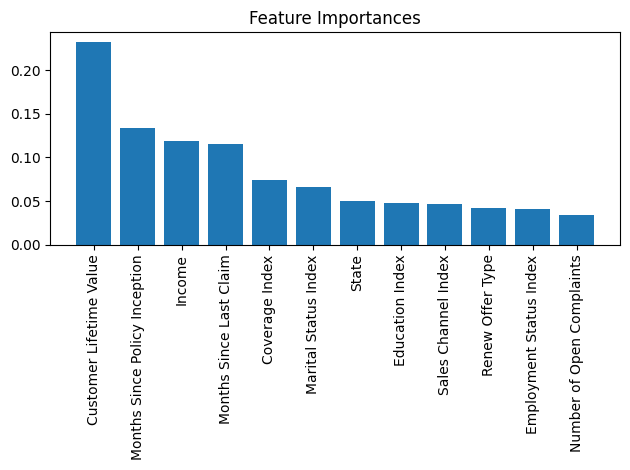

In [32]:

## Feature importance
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained random forest model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure()
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

## Model selection

This is a classification problem since we have feautres selected and we want to classify, given the features, weather or not claim over 1k is true or false.

I am planning to use k fold cross validation to test multiple models and find the best averaged scored model.

In [21]:
# Assuming 'df_new' is your DataFrame and 'Claim over 1k' is the target variable
X = df_new.drop(columns=['Claim over 1k', 'CustomerID'])  # Features
y = df_new['Claim over 1k']  # Target

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Define models you want to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [23]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5)  # 5-fold cross-validation

In [24]:
# Automated model evaluation storage
results_list = []  # Use a list to store intermediate results

# Loop through models
for model_name, model in models.items():
    # Perform cross-validation
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')  # Use 'accuracy' as the evaluation metric
    avg_score = scores.mean()
    
    # Store the results in a dictionary first
    results_list.append({'Model': model_name, 'Average Score': avg_score})

# Convert the list of results into a DataFrame
results_df = pd.DataFrame(results_list)

c:\Users\06pau\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\06pau\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [25]:
# Display the results
results_df

,Model,Average Score
0,Logistic Regression,0.893553
1,Random Forest,0.910014
2,SVM,0.886694
